## Importing the Dependencies

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor

## Data Collection & Analysis

In [10]:
# loading the data from csv file to a Pandas DataFrame
insurance_dataset = pd.read_csv('insurance.csv')

In [11]:
# getting some informations about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**Categorical Features**:
- Sex
- Smoker
- Region

In [12]:
# checking for missing values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data Analysis

In [13]:
# statistical Measures of the dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Visualization

### Heatmap

<Axes: >

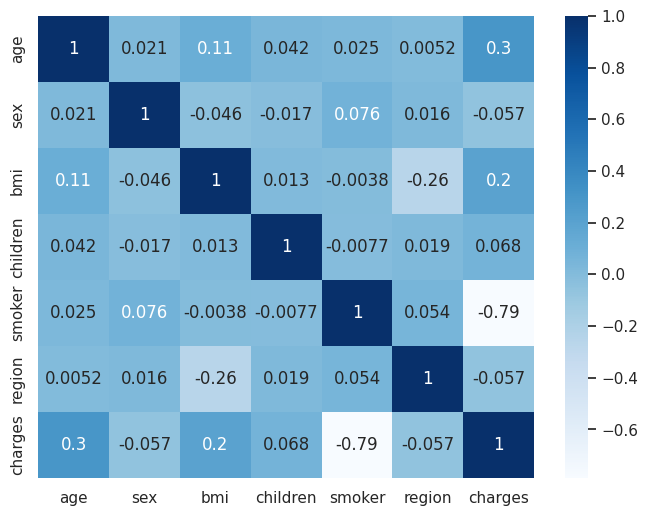

In [ ]:
plt.figure(figsize=(8,6))
sn.heatmap(insurance_dataset.corr(), annot=True, cmap='Blues')

### Pairplot

### Distribution plot

<ipython-input-8-28228e9c3528>:4: UserWarning: 



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.



Please adapt your code to use either `displot` (a figure-level function with

similar flexibility) or `histplot` (an axes-level function for histograms).



For a guide to updating your code to use the new functions, please see

https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



  sns.distplot(insurance_dataset['age'])


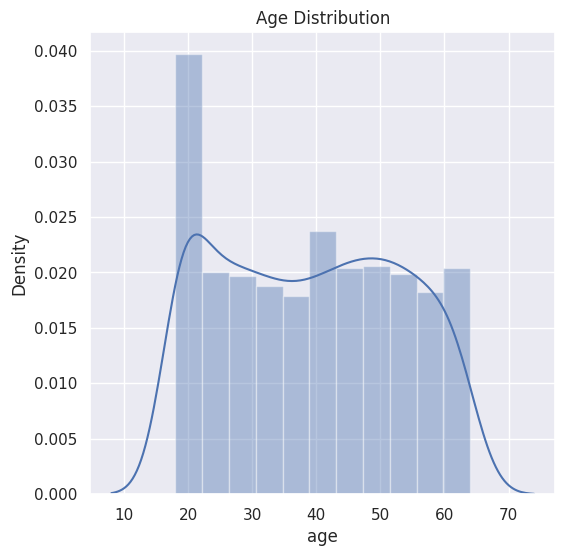

In [ ]:
# distribution of age value
sn.set()
plt.figure(figsize=(6,6))
sn.distplot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

### Countplot

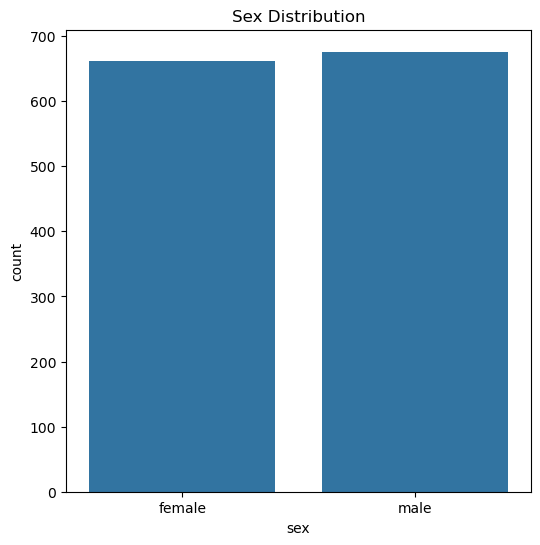

In [15]:
# Gender column
plt.figure(figsize=(6,6))
sn.countplot(x='sex', data=insurance_dataset)
plt.title('Sex Distribution')
plt.show()

In [16]:
# 'sex' column total value counts
insurance_dataset['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_4764\3096492476.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(insurance_dataset['bmi'])


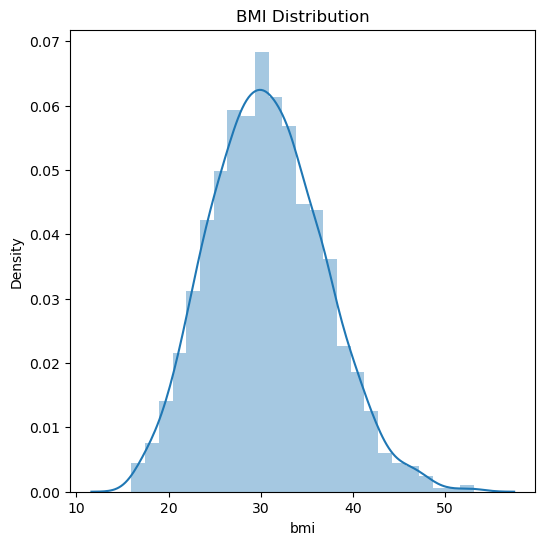

In [43]:
# bmi distribution
plt.figure(figsize=(6,6))
sn.distplot(insurance_dataset['bmi'])
plt.title('BMI Distribution')
plt.show()

**Normal BMI Range --> 18.5 to 24.9**

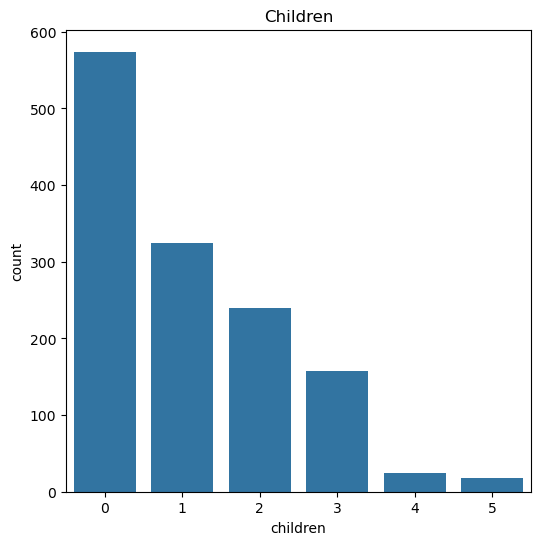

In [69]:
# children column
plt.figure(figsize=(6,6))
sn.countplot(x='children', data=insurance_dataset)
plt.title('Children')
plt.show()

In [70]:
insurance_dataset['smoker'].value_counts()

smoker
1    1064
0     274
Name: count, dtype: int64

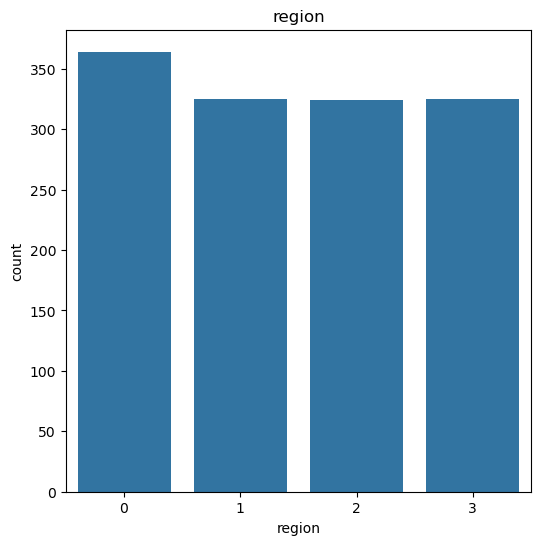

In [71]:
# region column
plt.figure(figsize=(6,6))
sn.countplot(x='region', data=insurance_dataset)
plt.title('region')
plt.show()

In [72]:
insurance_dataset['region'].value_counts()

region
0    364
1    325
3    325
2    324
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_4764\2806613346.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(insurance_dataset['charges'])


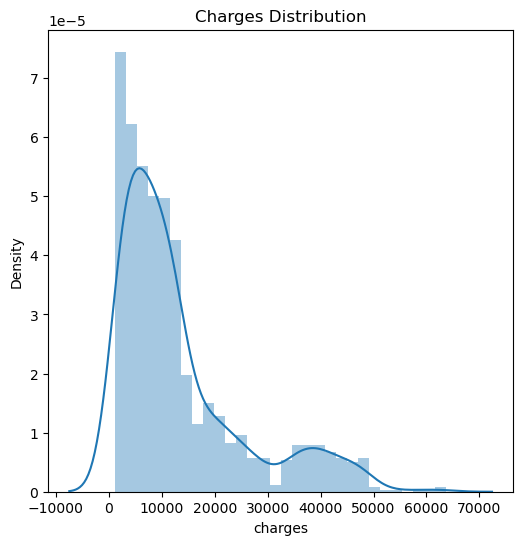

In [73]:
# distribution of charges value
plt.figure(figsize=(6,6))
sn.distplot(insurance_dataset['charges'])
plt.title('Charges Distribution')
plt.show()

## Data Pre-Processing

### Encoding the categorical features

In [74]:
# encoding sex column
insurance_dataset.replace({'sex':{'male':0,'female':1}}, inplace=True)

3 # encoding 'smoker' column
insurance_dataset.replace({'smoker':{'yes':0,'no':1}}, inplace=True)

# encoding 'region' column
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

In [75]:
X = insurance_dataset.drop(columns='charges', axis=1)
Y = insurance_dataset['charges']

## Splitting the data into Training data & Testing Data

In [76]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [77]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


# Model Training

## Linear Regression

In [78]:
# loading the Linear Regression model
regressor = LinearRegression()

In [79]:
regressor.fit(X_train, Y_train)

LinearRegression()

### Accuracy

In [80]:
# prediction on training data
training_data_prediction =regressor.predict(X_train)

In [81]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.751505643411174


In [82]:
# prediction on test data
test_data_prediction =regressor.predict(X_test)

In [83]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7447273869684076


## Random Forest

In [84]:
dt=RandomForestRegressor(n_estimators=10)
dt.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=10)

In [85]:
y_pred=dt.predict(X_train)
train_acc=metrics.r2_score(Y_train,y_pred)

train_acc

0.9682810025472024

In [86]:
y1_pred=dt.predict(X_test)
test_acc=metrics.r2_score(Y_test,y1_pred)

test_acc

0.8266977095568233

## XGBoost

In [87]:
xb=XGBRFRegressor()
xb.fit(X_train,Y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

### Accuracy

In [88]:
z_pred=xb.predict(X_train)
trainn_acc=metrics.r2_score(Y_train,z_pred)

trainn_acc

0.9060514119433907

In [89]:
z1_pred=xb.predict(X_test)
testt_acc=metrics.r2_score(Y_test,z1_pred)

testt_acc

0.8668172410197148

## Decision Tree

In [90]:
mt=DecisionTreeRegressor()
mt.fit(X_train,Y_train)

DecisionTreeRegressor()

## Accuracy

In [91]:
x_pred=mt.predict(X_train)
trainnn_acc=metrics.r2_score(Y_train,x_pred)

trainnn_acc

1.0

In [92]:
x1_pred=mt.predict(X_test)
testtt_acc=metrics.r2_score(Y_test,x1_pred)

testtt_acc

0.6918123890289494

## Building a Predictive System

In [93]:
input_data = (31,1,25.74,0,1,0)

# changing input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ', prediction[0])

[3760.0805765]
The insurance cost is USD  3760.080576496048


c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
